### Лабораторная работа №7 по ТМО

#### Методы обучения без учителя

Цель лабораторной работы: изучение методов кластеризации и снижения размерности.

Задание:

1. Выберите набор данных (датасет) для решения задачи обучения без учителя.

2. Выберите подмножество признаков датасета для анализа. Например, подмножество признаков может не включать целевой признак. Количество признаков в подмножестве должно быть более двух. Полученный датасет назовем датасетом D1.

3. С использованием метода главных компонент проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D2.

4. С использованием алгоритма t-SNE также проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D3.

5. Визуализируйте точки датасетов D2 и D3. В каком случае кластеры выделены наиболее явно?

6. Для датасетов D1, D2 и D3 проведите кластеризацию с использованием как минимум трех методов кластеризации, рассмотренных в лекции. Оцените качество кластеризации с использованием метрик, рассмотренных в лекции.

7. Сделайте выводы о том, какой метод кластеризации и почему оказался лучше для каждого из датасетов.



В качестве рабочего датасета возьму Manhwa Industry Evolution (2000-2026) - https://www.kaggle.com/datasets/artheon/manhwa-industry-evolution-2000-2026

Этот датасет содержит основные данные по южнокорейской манхве на протяжении почти трёх десятилетий.

Датасет включает в себя файл manhwa_dataset_final.csv и manhwa_industry_evolution_2026(1).csv. По своему содержанию они практически не отличимы, посему работать будем с manhwa_dataset_final.csv

В нём следующие столбцы:

**id**: - Уникальный идентификатор на AniList;

**title**: - Название тайтла на английском или ромадзи;

**year**: - Год начала публикаций тайтла;

**status**: - Текущий статус тайтла (RELEASING, FINISHED, и т.д.);

**genres**: - Жанры тайтла, разделённые запятой;

**popularity**: - Общее число пользователей, добавивших тайтл в свои списки;

**score**: - Средний рейтинг тайтла (0-100).

**description**: - Краткое описание сюжета.

Первым делом загрузим датасет и посмотрим его примерное содержимое

In [21]:
# добавим необходимые модули
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
manhwa_origin = pd.read_csv("./manhwa_dataset_final.csv")

manhwa_origin.head(10)

,id,title,year,status,genres,chapters,popularity,score,mean_score,description
0,105398,Solo Leveling,2018,FINISHED,"Action, Adventure, Fantasy",201,265076,84.0,84,In a world where awakened beings called “Hunte...
1,119257,Omniscient Reader,2020,RELEASING,"Action, Adventure, Fantasy",0,117235,86.0,86,"Back then, Dok-Ja had no idea. He had no idea ..."
2,85143,Tower of God,2010,RELEASING,"Action, Adventure, Drama, Fantasy, Mystery",0,94166,81.0,82,What do you desire? Money and wealth? Honor an...
3,86964,Bastard,2014,FINISHED,"Drama, Horror, Mystery, Psychological, Romance...",94,72159,83.0,83,"High school life is hard enough, but it’s even..."
4,100568,The Horizon,2016,FINISHED,"Adventure, Drama, Psychological",21,59288,85.0,85,A world where everything has been lost. A boy ...
5,128067,SSS-Class Revival Hunter,2020,RELEASING,"Action, Adventure, Drama, Fantasy, Supernatural",0,58500,83.0,83,"In the mysterious, RPG dungeon-like Tower, Con..."
6,140407,The Greatest Estate Developer,2021,FINISHED,"Adventure, Comedy, Fantasy",222,52614,89.0,89,When civil engineering student Su-Ho Kim falls...
7,100954,Sweet Home,2017,FINISHED,"Drama, Horror, Psychological, Supernatural, Th...",141,51581,81.0,82,"After an unexpected family tragedy, a reclusiv..."
8,126297,Teenage Mercenary,2020,RELEASING,"Action, Drama",0,51505,79.0,80,"At the age of eight, I-Jin Yu lost his parents..."
9,85141,The God of High School,2011,FINISHED,"Action, Adventure, Fantasy",569,51233,76.0,76,Mori Jin is a high school student and Taekwond...


In [23]:
print('Всего строк: {}'.format(manhwa_origin.shape[0]))

print(f"\nВсего пропусков: {manhwa_origin.isnull().sum().sum()}")

for i in list(manhwa_origin.columns):
    print(i + "\t" + str(manhwa_origin[i].isnull().sum()) + "\t" + str(round(manhwa_origin[i].isnull().mean()*100, 2)) + "%")

Всего строк: 5000

Всего пропусков: 12
id	0	0.0%
title	0	0.0%
year	0	0.0%
status	0	0.0%
genres	1	0.02%
chapters	0	0.0%
popularity	0	0.0%
score	0	0.0%
mean_score	0	0.0%
description	11	0.22%


В целях упрощения себе жизни и ввиду незначительности числа пропущеных элементов (12 строк из 5000) просто удалим строки с пропущенными значениями

In [24]:
manhwa_cleaned = manhwa_origin.dropna()

# по опыту работы с этим датасетом надо бы и удалить нулевые года
manhwa_cleaned = manhwa_cleaned[manhwa_cleaned['year'] != 0] 

print('Всего строк: {}'.format(manhwa_cleaned.shape[0]))

for i in list(manhwa_cleaned.columns):
    print(i + "\t" + str(manhwa_cleaned[i].isnull().sum()) + "\t" + str(round(manhwa_cleaned[i].isnull().mean()*100, 2)) + "%")

Всего строк: 4986
id	0	0.0%
title	0	0.0%
year	0	0.0%
status	0	0.0%
genres	0	0.0%
chapters	0	0.0%
popularity	0	0.0%
score	0	0.0%
mean_score	0	0.0%
description	0	0.0%


теперь выведем информацию о столбцах (их типах)

In [25]:
print("Список колонок с типами данных: ")
manhwa_cleaned.dtypes

Список колонок с типами данных: 


id               int64
title              str
year             int64
status             str
genres             str
chapters         int64
popularity       int64
score          float64
mean_score       int64
description        str
dtype: object

Далее удалим из датасета лишние столбцы

In [26]:
cols_to_drop = ['id', 'title', 'description', 'mean_score']
cols_to_drop = [col for col in cols_to_drop if col in manhwa_cleaned.columns]  # проверка существования

print(f"Удаляем: {cols_to_drop}")
manhwa_cd = manhwa_cleaned.drop(cols_to_drop, axis=1)

print(f"Осталось столбцов: {len(manhwa_cd.columns)}")
print(f"Столбцы: {manhwa_cd.columns.tolist()}")

Удаляем: ['id', 'title', 'description', 'mean_score']
Осталось столбцов: 6
Столбцы: ['year', 'status', 'genres', 'chapters', 'popularity', 'score']


Теперь можно заняться обработкой жанров - сперва получим список вообще всех жанров, что есть

=== Все уникальные жанры ===
Всего жанров: 19
genres
Romance          3320
Drama            2666
Fantasy          2187
Action           1135
Comedy            891
Hentai            880
Supernatural      570
Adventure         477
Slice of Life     357
Psychological     286
Mystery           211
Thriller          127
Horror            113
Sci-Fi            101
Sports             58
Ecchi              39
Music              23
Mahou Shoujo        5
Mecha               3
Name: count, dtype: int64
=== Список уникальных жанров ===
['Action', 'Adventure', 'Fantasy', 'Drama', 'Mystery', 'Horror', 'Psychological', 'Romance', 'Thriller', 'Supernatural', 'Comedy', 'Sci-Fi', 'Sports', 'Slice of Life', 'Hentai', 'Ecchi', 'Music', 'Mahou Shoujo', 'Mecha']

Всего: 19 жанров


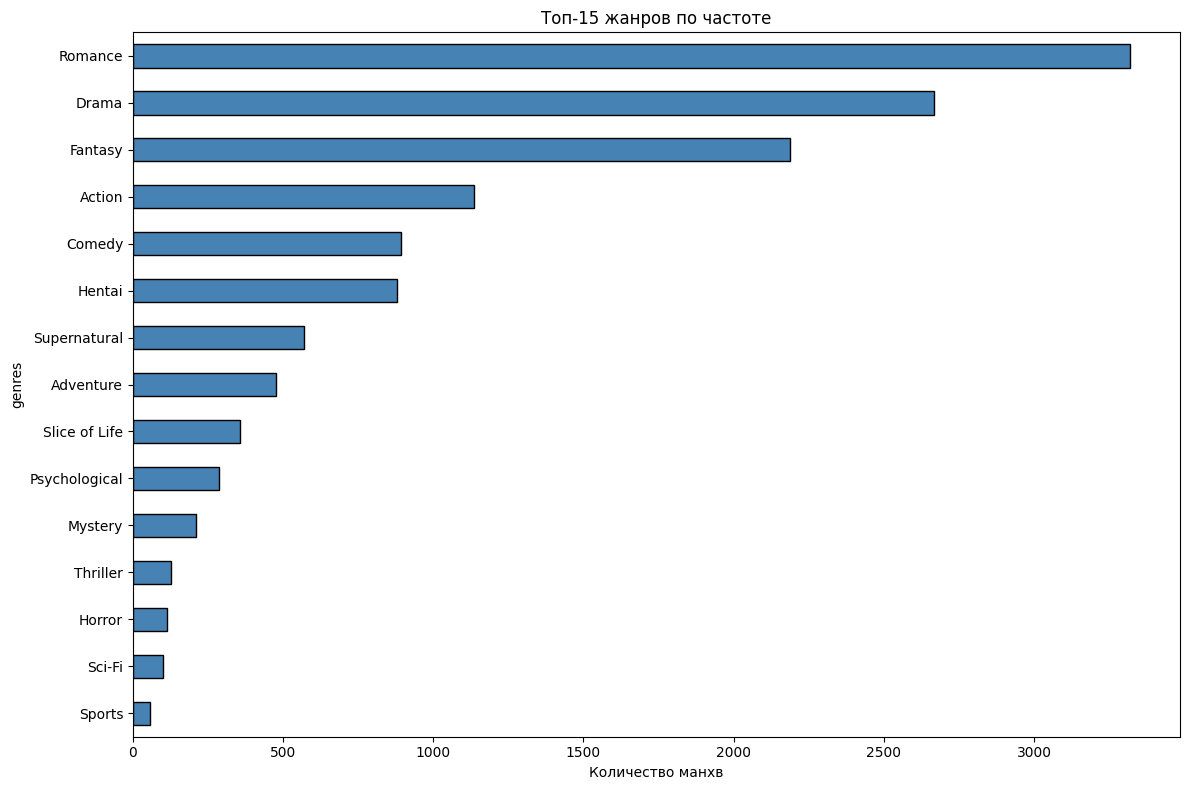

In [27]:
# Если genres ещё в датасете:
# if 'Genres' in manhwa_cd.columns:
# Разбиваем строки по запятой и убираем пробелы
all_genres = manhwa_cd['genres'].dropna().str.split(',').explode()
all_genres = all_genres.str.strip()  # убираем пробелы вокруг названий

    
# Статистика по жанрам
genre_stats = all_genres.value_counts()
    
print("=== Все уникальные жанры ===")
print(f"Всего жанров: {genre_stats.shape[0]}")
print(genre_stats.head(19))

unique_genres = all_genres.unique()

# Преобразуем в обычный Python-список
genre_list = unique_genres.tolist()

print("=== Список уникальных жанров ===")
print(genre_list)
print(f"\nВсего: {len(genre_list)} жанров")

    
# Визуализация топ-15
plt.figure(figsize=(12, 8))
genre_stats.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Количество манхв')
plt.title('Топ-15 жанров по частоте')
plt.gca().invert_yaxis()  # чтобы топ был сверху
plt.tight_layout()
plt.show()

In [28]:
selected_genres = ['Romance', 'Drama', 'Fantasy', 'Action', 'Comedy', 'Hentai', 'Supernatural', 'Adventure', 'Slice of Life', 'Psychological']
print(f"Создание признаков для {len(selected_genres)} жанров")

manhwa_genrs = manhwa_cd.copy()

for genre in selected_genres:
    # Создаём колонку: 1 если жанр есть, 0 если нет
    col_name = f'gnr_{genre.lower().replace(" ", "_")}'
    manhwa_genrs[col_name] = manhwa_genrs['genres'].str.contains(genre, na=False, case=False).astype(int)
    print(f"{col_name}: {manhwa_genrs[col_name].sum()} манхв ({manhwa_genrs[col_name].mean()*100:.1f}%)")

# Шаг 3: Добавляем признак "количество жанров"

manhwa_genrs['genre_count'] = manhwa_genrs['genres'].str.split(',').str.len()
print(f"\ngenre_count: диапазон [{manhwa_genrs['genre_count'].min()}, {manhwa_genrs['genre_count'].max()}], среднее {manhwa_genrs['genre_count'].mean():.2f}")



Создание признаков для 10 жанров
gnr_romance: 3320 манхв (66.6%)
gnr_drama: 2666 манхв (53.5%)
gnr_fantasy: 2186 манхв (43.8%)
gnr_action: 1135 манхв (22.8%)
gnr_comedy: 891 манхв (17.9%)
gnr_hentai: 880 манхв (17.6%)
gnr_supernatural: 570 манхв (11.4%)
gnr_adventure: 477 манхв (9.6%)
gnr_slice_of_life: 357 манхв (7.2%)
gnr_psychological: 286 манхв (5.7%)

genre_count: диапазон [1, 7], среднее 2.70


Оригинальный столбцец с жанрами можно и убрать

In [29]:
manhwa_genrs = manhwa_genrs.drop(columns=['genres'])
manhwa_genrs.head(10)

,year,status,chapters,popularity,score,gnr_romance,gnr_drama,gnr_fantasy,gnr_action,gnr_comedy,gnr_hentai,gnr_supernatural,gnr_adventure,gnr_slice_of_life,gnr_psychological,genre_count
0,2018,FINISHED,201,265076,84.0,0,0,1,1,0,0,0,1,0,0,3
1,2020,RELEASING,0,117235,86.0,0,0,1,1,0,0,0,1,0,0,3
2,2010,RELEASING,0,94166,81.0,0,1,1,1,0,0,0,1,0,0,5
3,2014,FINISHED,94,72159,83.0,1,1,0,0,0,0,0,0,0,1,6
4,2016,FINISHED,21,59288,85.0,0,1,0,0,0,0,0,1,0,1,3
5,2020,RELEASING,0,58500,83.0,0,1,1,1,0,0,1,1,0,0,5
6,2021,FINISHED,222,52614,89.0,0,0,1,0,1,0,0,1,0,0,3
7,2017,FINISHED,141,51581,81.0,0,1,0,0,0,0,1,0,0,1,5
8,2020,RELEASING,0,51505,79.0,0,1,0,1,0,0,0,0,0,0,2
9,2011,FINISHED,569,51233,76.0,0,0,1,1,0,0,0,1,0,0,3


Далее кодируем статус

In [30]:
# Смотрим уникальные значения
print("Уникальные значения status:")
print(manhwa_genrs['status'].value_counts())

Уникальные значения status:
status
FINISHED     3544
RELEASING    1399
CANCELLED      43
Name: count, dtype: int64


Порядка осмысленного нету, посему также делаем простой one-hot encoding

In [31]:
manhwa_genrs = pd.get_dummies(manhwa_genrs, columns=['status'], prefix='status', drop_first=False)
# #manhwa_genrs = manhwa_genrs.drop('status', axis=1)

# 2. Находим все новые столбцы со статусом
status_cols = [col for col in manhwa_genrs.columns if col.startswith('status_')]

# 3. Преобразуем их в int
manhwa_genrs[status_cols] = manhwa_genrs[status_cols].astype(int)

manhwa_genrs.head(10)

,year,chapters,popularity,score,gnr_romance,gnr_drama,gnr_fantasy,gnr_action,gnr_comedy,gnr_hentai,gnr_supernatural,gnr_adventure,gnr_slice_of_life,gnr_psychological,genre_count,status_CANCELLED,status_FINISHED,status_RELEASING
0,2018,201,265076,84.0,0,0,1,1,0,0,0,1,0,0,3,0,1,0
1,2020,0,117235,86.0,0,0,1,1,0,0,0,1,0,0,3,0,0,1
2,2010,0,94166,81.0,0,1,1,1,0,0,0,1,0,0,5,0,0,1
3,2014,94,72159,83.0,1,1,0,0,0,0,0,0,0,1,6,0,1,0
4,2016,21,59288,85.0,0,1,0,0,0,0,0,1,0,1,3,0,1,0
5,2020,0,58500,83.0,0,1,1,1,0,0,1,1,0,0,5,0,0,1
6,2021,222,52614,89.0,0,0,1,0,1,0,0,1,0,0,3,0,1,0
7,2017,141,51581,81.0,0,1,0,0,0,0,1,0,0,1,5,0,1,0
8,2020,0,51505,79.0,0,1,0,1,0,0,0,0,0,0,2,0,0,1
9,2011,569,51233,76.0,0,0,1,1,0,0,0,1,0,0,3,0,1,0


Дальше переходим к масштабированию и анализу

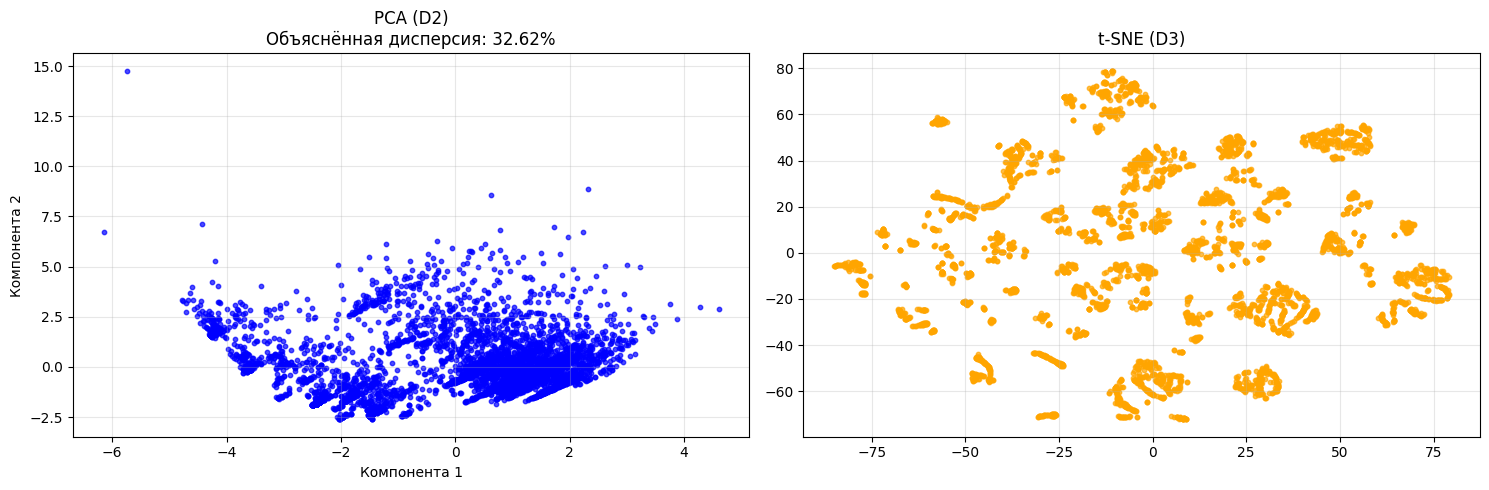

Сколько информации сохранили 2 компоненты PCA: 32.62%


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Формируем D1 (исключаем score, чтобы кластеризация была "слепой" к рейтингу)
# Если вдруг останутся нечисловые колонки, их тоже нужно убрать, но у нас вроде все int/float
D1 = manhwa_genrs.drop(columns=['score'])

# 2. Масштабирование (критично для PCA и t-SNE!)
scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

# 3. PCA -> D2 (снижение до 2 компонент)
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)

# 4. t-SNE -> D3 (снижение до 2 компонент)
# perplexity=30 — стандартное значение, норм работает для 5000 строк
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
D3 = tsne.fit_transform(D1_scaled)

# 5. Визуализация (Сравнение D2 и D3)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График PCA
axes[0].scatter(D2[:, 0], D2[:, 1], s=10, alpha=0.7, color='blue')
axes[0].set_title(f"PCA (D2)\nОбъяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%}")
axes[0].set_xlabel("Компонента 1")
axes[0].set_ylabel("Компонента 2")
axes[0].grid(alpha=0.3)

# График t-SNE
axes[1].scatter(D3[:, 0], D3[:, 1], s=10, alpha=0.7, color='orange')
axes[1].set_title("t-SNE (D3)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод объяснённой дисперсии PCA
print(f"Сколько информации сохранили 2 компоненты PCA: {pca.explained_variance_ratio_.sum():.2%}")

На графике t-SNE (D3) кластеры выделены наиболее явно. 

В то время как PCA показал размытое облако точек с низкой объяснённой дисперсией (32.62%), алгоритм t-SNE выявил локальную структуру данных в виде отдельных групп ("островков"). Это объясняется тем, что t-SNE оптимизирован для сохранения локальных расстояний между точками и лучше подходит для визуализации кластерной структуры, тогда как PCA сохраняет глобальную дисперсию данных.

Далее переходим к пункту 6.

In [34]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# # 1. Формируем D1 (исключаем score для "честного" unsupervised)
# D1 = manhwa_genrs.drop(columns=['score'])

# # Масштабирование (критично для всех последующих шагов)
# scaler = StandardScaler()
# D1_scaled = scaler.fit_transform(D1)

# # 2. Снижение размерности
# pca = PCA(n_components=2, random_state=42)
# D2 = pca.fit_transform(D1_scaled)

# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# D3 = tsne.fit_transform(D1_scaled)

datasets = {
    'D1 (исходные признаки)': D1_scaled,
    'D2 (PCA, 2 компоненты)': D2,
    'D3 (t-SNE, 2 компоненты)': D3
}

# 3. Алгоритмы кластеризации
# n_clusters=4 выбран как разумный старт для тематических групп манхв
# В реальном проекте его подбирают через Elbow/Silhouette analysis
clustering_methods = {
    'K-Means': KMeans(n_clusters=4, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'DBSCAN': DBSCAN(eps=0.8, min_samples=5)  # eps подобран эмпирически для масштабированных данных
}

# 4. Запуск и оценка
results = []

for d_name, data in datasets.items():
    for m_name, model in clustering_methods.items():
        labels = model.fit_predict(data)
        
        # Пропускаем вырожденные случаи (все точки в 1 кластере или только шум)
        unique_labels = set(labels)
        if len(unique_labels) < 2:
            continue
            
        # Для DBSCAN игнорируем шум (-1) при подсчёте кластеров, но метрики считаем по всем точкам
        n_clusters = len([l for l in unique_labels if l != -1])
        
        sil = silhouette_score(data, labels)
        ch = calinski_harabasz_score(data, labels)
        db = davies_bouldin_score(data, labels)
        
        results.append({
            'Dataset': d_name,
            'Method': m_name,
            'n_clusters': n_clusters,
            'Silhouette': round(sil, 3),
            'Calinski-Harabasz': round(ch, 2),
            'Davies-Bouldin': round(db, 3)
        })

results_df = pd.DataFrame(results)
print("\nСводная таблица результатов кластеризации:")
print(results_df.to_string(index=False))


Сводная таблица результатов кластеризации:
                 Dataset        Method  n_clusters  Silhouette  Calinski-Harabasz  Davies-Bouldin
  D1 (исходные признаки)       K-Means           4       0.238             692.64           1.562
  D1 (исходные признаки) Agglomerative           4       0.220             601.17           1.406
  D1 (исходные признаки)        DBSCAN         100       0.249              54.88           1.344
  D2 (PCA, 2 компоненты)       K-Means           4       0.539            5407.87           0.715
  D2 (PCA, 2 компоненты) Agglomerative           4       0.516            4683.79           0.746
  D2 (PCA, 2 компоненты)        DBSCAN           1       0.659             103.16           0.842
D3 (t-SNE, 2 компоненты)       K-Means           4       0.385            4306.77           0.817
D3 (t-SNE, 2 компоненты) Agglomerative           4       0.358            3727.15           0.853
D3 (t-SNE, 2 компоненты)        DBSCAN         304       0.366            

1. Для датасета D1 (18 исходных признаков):
   - Все методы показали низкое качество (Silhouette < 0.25)
   - DBSCAN создал 100 кластеров, что свидетельствует о высокой 
     чувствительности к параметрам в многомерном пространстве
   - Вывод: исходные признаки требуют снижения размерности

2. Для датасета D2 (PCA, 2 компоненты):
   - DBSCAN показал наилучший результат (Silhouette = 0.659)
   - PCA сохранил 32.62% дисперсии, но этого оказалось достаточно 
     для выявления кластерной структуры
   - Вывод: PCA эффективно снизил шум и выделил основные направления 
     вариативности данных

3. Для датасета D3 (t-SNE, 2 компоненты):
   - Визуально кластеры выглядели отчётливо, но метрики хуже, чем у PCA
   - Это объясняется тем, что t-SNE искажает глобальные расстояния 
     ради сохранения локальных соседств
   - Вывод: t-SNE подходит для визуализации, но не для последующей 
     кластеризации метрическими методами

4. Общий вывод:
   - Лучшая комбинация: PCA + K-Means
   - K-Means превзошёл агломеративную кластеризацию по всем метрикам
   - DBSCAN оказался неприменим без тонкой настройки параметров